# LSTM: Trajectory Regression + 3‑Klassen‑Wurfklassifikation
Dieses Notebook implementiert **genau die gewünschte Aufteilung**:
- **Modus A (noisy)**  (vollständige Sequenz → vollständige Sequenz)
- **Modus B (clean-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste cleanen 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)
- **Modus C (noisy-trimmed / Extrapolation)**: `ExtrapSeq2SeqModel` (erste noisy 30 Punkte konditionieren → **vollständig vorhergesagte** Trajektorie mit 50 Punkten)

Es erzeugt synthetische Ballistik‑Trajektorien, baut **Train/Validation/Test**‑Splits, trainiert die Modelle und evaluiert Regression & Klassifikation.


In [1]:

# 0) Imports & Setup
import os, random
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, Optional, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Daten laden

In [2]:
# Daten-Datei (CSV) – hier entweder im Notebook-Ordner oder im /mnt/data Ordner.
CSV_PATH = "free_throw_dataset.csv"
if not os.path.exists(CSV_PATH):
    alt = os.path.join("/mnt/data", CSV_PATH)
    if os.path.exists(alt):
        CSV_PATH = alt

df = pd.read_csv(CSV_PATH)
df["point_index"] = df.groupby("wurf_id").cumcount()
print("CSV_PATH:", CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

CSV_PATH: free_throw_dataset.csv
(7500, 13)
['wurf_id', 't', 'x_clean', 'y_clean', 'x_noisy', 'y_noisy', 'x', 'y', 'T', 'label', 'theta', 'v0', 'point_index']


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0,point_index
0,0,0.000000,0.000000,2.662500,0.157921,2.578578,0.157921,2.578578,0.696893,0,0.70767,6.107672,0
1,0,0.014222,0.066007,2.717976,0.142750,2.687055,0.142750,2.687055,0.696893,0,0.70767,6.107672,1
2,0,0.028445,0.132014,2.771469,0.085067,2.804595,0.085067,2.804595,0.696893,0,0.70767,6.107672,2
3,0,0.042667,0.198021,2.822978,0.252277,2.920532,0.252277,2.920532,0.696893,0,0.70767,6.107672,3
4,0,0.056889,0.264028,2.872503,0.217686,2.824585,0.217686,2.824585,0.696893,0,0.70767,6.107672,4


In [3]:
# Pro Wurf aggregieren
per_throw = (
    df.groupby("wurf_id")
    .agg({"label": "first", "theta": "first", "v0": "first", "T": "first"})
    .reset_index()
)

print("Anzahl Würfe:", per_throw.shape[0])
print(per_throw["label"].value_counts())
per_throw.head()

Anzahl Würfe: 150
label
0    50
1    50
2    50
Name: count, dtype: int64


,wurf_id,label,theta,v0,T
0,0,0,0.707670,6.107672,0.696893
1,1,1,0.889089,6.662367,0.974337
2,2,2,0.759879,6.803414,0.864825
3,3,0,0.762547,6.383944,0.801193
4,4,1,0.793452,6.633317,0.874307


In [4]:
train_ids, test_ids = train_test_split(
    per_throw["wurf_id"].values,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw["label"].values,
)
train_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.15,
    random_state=SEED,
    stratify=per_throw.set_index("wurf_id").loc[train_ids, "label"].values,
)

print("Train/Val/Test:", len(train_ids), len(val_ids), len(test_ids))
print("Alle Test ids:", test_ids)

df_train = (
    df[df["wurf_id"].isin(train_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_val = (
    df[df["wurf_id"].isin(val_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)
df_test = (
    df[df["wurf_id"].isin(test_ids)]
    .sort_values(["wurf_id", "point_index"])
    .reset_index(drop=True)
)

Train/Val/Test: 107 20 23
Alle Test ids: [131 119  84 124  24  22   9  11  89  57 148  31  69  85  71 141   1  41
 117 106  42 143  70]


## 3) Scaling (fit auf Train)

In [5]:
# 1) XY-Preprocessing: physikalische Einheiten als Referenz
#
# Für den Vergleich mit dem amortisierten PINN werden (x,y) standardmäßig **nicht** standardisiert,
# d. h. alle Koordinaten bleiben im SI-Raum (Meter). Optional kann Standardisierung für Ablationen
# aktiviert werden, sollte dann aber explizit dokumentiert werden.

USE_XY_STANDARDIZATION = False  # Vergleich: False (Meter-Raum)

class IdentityScaler:
    """No-op Scaler: transformiert nicht (Einheiten bleiben Meter).
    mean_/std_ sind definiert, damit Downstream-Code (z. B. Ringhöhe im Modellraum) konsistent bleibt.
    """
    def __init__(self):
        self.mean_ = np.zeros((1, 2), dtype=np.float32)
        self.std_  = np.ones((1, 2), dtype=np.float32)

    def fit(self, xy: np.ndarray):
        return self

    def transform(self, xy: np.ndarray) -> np.ndarray:
        return xy.astype(np.float32, copy=False)

    def inverse_transform(self, xy_scaled: np.ndarray) -> np.ndarray:
        return xy_scaled.astype(np.float32, copy=False)


class XYScaler:
    """Standardisierung (optional)."""
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, xy: np.ndarray):
        self.mean_ = xy.mean(axis=0, keepdims=True)
        self.std_ = xy.std(axis=0, keepdims=True) + 1e-8
        return self

    def transform(self, xy: np.ndarray) -> np.ndarray:
        return (xy - self.mean_) / self.std_

    def inverse_transform(self, xy_scaled: np.ndarray) -> np.ndarray:
        return xy_scaled * self.std_ + self.mean_


# Fit/Init auf clean Koordinaten aus Train (nur für optionale Standardisierung relevant)
train_xy = df_train[["x_clean","y_clean"]].to_numpy(np.float32)

scaler = XYScaler().fit(train_xy) if USE_XY_STANDARDIZATION else IdentityScaler().fit(train_xy)

print("USE_XY_STANDARDIZATION:", USE_XY_STANDARDIZATION)
print("scaler.mean_:", scaler.mean_)
print("scaler.std_ :", scaler.std_)


USE_XY_STANDARDIZATION: False
scaler.mean_: [[0. 0.]]
scaler.std_ : [[1. 1.]]


## 4) Dataset

In [6]:
def df_to_wurf_arrays(df: pd.DataFrame):
    # group each wurf into arrays ordered by point_index
    groups = []
    for wid, g in df.groupby("wurf_id"):
        g = g.sort_values("point_index")
        groups.append(g)
    return groups


class ExtrapolationDataset(Dataset):
    """Seq2Seq-Setup **ohne Horizont-/Endzeitpunkt-Wissen im Decoder**.

    - Encoder sieht die ersten Tin Punkte (x,y,t_norm) aus dem Beobachtungsfenster.
    - Decoder bekommt **keine** vollständige Zeitachse t_all, sondern nur ein aus den beobachteten Zeiten
      geschätztes Δt (hier: mittlere Schrittweite in *normalisierter* Zeit).
    - y_all enthält weiterhin die komplette Trajektorie (T,2). Diese Information kann strikt
      als "Oracle" für **Evaluation/Reporting** genutzt werden, ohne dass sie im Training als Loss-Signal
      in den Zukunftsteil zurückfließt (Partial-Observation-Szenario).
    """
    def __init__(self, df, scaler, tin, input_source="clean", target_source="clean"):
        self.df = df
        self.scaler = scaler
        self.tin = tin
        self.input_source = input_source
        self.target_source = target_source

        # >>> neu: wurf_id-Liste + Gruppen, damit wir für idx wieder an die Rohdaten kommen
        self.throw_ids = list(self.df["wurf_id"].unique())
        self.groups = {k: g.sort_values("point_index").reset_index(drop=True)
                       for k, g in self.df.groupby("wurf_id")}

    def __len__(self):
        return len(self.throw_ids)

    def __getitem__(self, idx):
        wid = self.throw_ids[idx]
        g = self.groups[wid]
        label = int(g["label"].iloc[0])

        T = len(g)
        assert self.tin <= T

        # --- time normalization without future knowledge ---
        t = g["t"].to_numpy(np.float32)[:, None]        # (T,1) absolute time (seconds)
        t_min = float(t[0, 0])
        t_obs_max = float(t[self.tin - 1, 0])           # last observed time

        denom = max(1e-8, (t_obs_max - t_min))          # guard against tin==1 or degenerate
        t_n = (t - t_min) / denom                       # observed in [0,1], future > 1
        # --------------------------------------------------

        # Δt ausschließlich aus dem Beobachtungsfenster (Tin) ableiten
        if self.tin >= 2:
            dt_n = float(np.mean(np.diff(t_n[: self.tin, 0])))
        else:
            dt_n = 0.0

        xy_clean = g[["x_clean","y_clean"]].to_numpy(np.float32)
        xy_noisy = g[["x_noisy","y_noisy"]].to_numpy(np.float32)

        xy_in  = xy_noisy if self.input_source=="noisy" else xy_clean
        xy_tgt = xy_clean if self.target_source=="clean" else xy_noisy

        xy_in_s  = self.scaler.transform(xy_in)    # (T,2)
        xy_tgt_s = self.scaler.transform(xy_tgt)   # (T,2)

        # Encoder input: (Tin,3) = [x,y,t_norm]
        x_in = np.concatenate([xy_in_s[:self.tin], t_n[:self.tin]], axis=1).astype(np.float32)

        # Full targets: (T,2)
        y_all = xy_tgt_s.astype(np.float32)

        return (
            torch.from_numpy(x_in),                                 # (Tin,3)
            torch.tensor([dt_n], dtype=torch.float32),              # (1,)
            torch.from_numpy(y_all),                                # (T,2)
            torch.tensor(label, dtype=torch.long)
        )


def collate_extrap(batch):
    # Pads are not needed: Tin and T are fixed by construction.
    x_in, dt, y_all, labels = zip(*batch)
    return (
        torch.stack(x_in, dim=0),     # (B,Tin,3)
        torch.stack(dt, dim=0),       # (B,1)
        torch.stack(y_all, dim=0),    # (B,T,2)
        torch.stack(labels, dim=0),   # (B,)
    )


## 5) Modelle

In [7]:
class ExtrapSeq2SeqModel(nn.Module):
    """Seq2Seq-LSTM für Trajektorien-Regression + 3-Klassen-Classification **ohne Decoder-Horizontwissen**.

    - Encoder: sieht die ersten Tin Punkte (x,y,t_norm).
    - Decoder: autoregressiv, Input pro Schritt: [prev_x, prev_y, Δt]
      wobei Δt ausschließlich aus den beobachteten Zeiten geschätzt wird.
    - Inferenz kann dynamisch bis zur Korbebene (y = h_ring) gerollt werden.

    Decoder wird im Beobachtungsfenster teacher-forced gewärmt und ist ab Extrapolation strikt autoregressiv (kein Teacher Forcing auf zukünftigen Punkten).
    """

    def __init__(self, input_dim=3, hidden_dim=128, num_layers=2, n_classes=3, dropout=0.1):
        super().__init__()
        self.enc = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),
        )
        # Decoder bekommt: prev_xy (2) + dt (1) => 3
        self.dec_cell = nn.LSTMCell(input_size=3, hidden_size=hidden_dim)
        self.out_head = nn.Linear(hidden_dim, 2)
        self.cls_head = nn.Linear(hidden_dim, n_classes)

    def forward(self, x_in, dt, n_future: int = 0, return_warmup_preds: bool = False):
        """Forward-Pass ohne GT-Horizontwissen.

        Args:
          x_in:    (B,Tin,3) = [x,y,t_norm] aus dem Beobachtungsfenster
          dt:      (B,1)     = Δt geschätzt nur aus beobachteten Zeiten (normalisierte Zeit)
          n_future: int      = Anzahl Zukunftsschritte, die *immer* ausgerollt werden
                              (Sicherheitsgrenze; **nicht** aus y_all oder T abgeleitet)
          return_warmup_preds: Wenn True, werden 1‑Step‑Predictions im Beobachtungsfenster zurückgegeben,
                               d.h. Vorhersagen für x_in[:,1:Tin,:2] unter Teacher Forcing.

        Returns:
          y_hat_full: (B,Tin+n_future,2)  (erste Tin Punkte = Input-XY; danach Decoder-Preds)
          logits:     (B,3)
          warmup_preds (optional): (B,Tin-1,2)  1‑Step‑Preds im Beobachtungsfenster
        """
        out, (hN, cN) = self.enc(x_in)      # out: (B,Tin,H)
        h = hN[-1]                           # (B,H)
        c = cN[-1]

        logits = self.cls_head(h)            # (B,3)

        B, Tin, _ = x_in.shape

        # ----------------------------
        # 1) Teacher-forced Warm-up über den beobachteten Teil
        #    Optional: 1‑Step‑Predictions im Beobachtungsfenster sammeln.
        # ----------------------------
        prev_xy = x_in[:, 0, :2]  # (B,2) scaled
        warm_preds = [] if return_warmup_preds else None

        for k in range(1, Tin):
            dec_in = torch.cat([prev_xy, dt], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))

            if return_warmup_preds:
                xy_hat = self.out_head(h)             # (B,2) -> Vorhersage für Schritt k
                warm_preds.append(xy_hat.unsqueeze(1))

            prev_xy = x_in[:, k, :2]                  # teacher forcing im Beobachtungsfenster

        # ----------------------------
        # 2) Autoregressiver Rollout für Zukunftsschritte (ohne Teacher Forcing)
        # ----------------------------
        preds_f = []
        for _ in range(int(n_future)):
            dec_in = torch.cat([prev_xy, dt], dim=1)  # (B,3)
            h, c = self.dec_cell(dec_in, (h, c))
            xy_next = self.out_head(h)                # (B,2)
            preds_f.append(xy_next.unsqueeze(1))
            prev_xy = xy_next                         # **immer** autoregressiv

        if int(n_future) > 0:
            y_future = torch.cat(preds_f, dim=1)      # (B,n_future,2)
            y_hat_full = torch.cat([x_in[:, :, :2], y_future], dim=1)
        else:
            y_hat_full = x_in[:, :, :2]

        if return_warmup_preds:
            if Tin <= 1:
                warmup_preds = torch.zeros((B, 0, 2), device=x_in.device, dtype=x_in.dtype)
            else:
                warmup_preds = torch.cat(warm_preds, dim=1)  # (B,Tin-1,2)
            return y_hat_full, logits, warmup_preds

        return y_hat_full, logits

    @torch.no_grad()
    def rollout_until_ring(self, x_in, dt, y_ring_scaled, max_steps=300):
        """Autoregressiver Rollout bis zur Korbebene ohne Horizontwissen im Decoder-Input.

        WICHTIG (Broadcasting-Sicherheit):
          - y_ring_scaled kann als float oder als Tensor der Form (B,), (B,1) oder skalar übergeben werden.
          - Intern wird es zu einem 1D-Tensor der Form (B,) normalisiert, damit logische Operationen
            nicht versehentlich zu (B,B)-Broadcasting führen.

        Returns:
          y_future: (B,S,2) Preds für Zukunftsschritte (S <= max_steps)
          stop_idx: (B,) Index (0..S-1) des Stop-Schritts im Zukunftstensor (falls nie: letzter Schritt)
          S:        int, tatsächliche Anzahl ausgegebener Steps
        """
        self.eval()

        B, Tin, _ = x_in.shape
        device = x_in.device
        dtype = x_in.dtype

        # -------- normalize y_ring_scaled to shape (B,) --------
        if torch.is_tensor(y_ring_scaled):
            y_ring = y_ring_scaled.to(device=device, dtype=dtype)
            if y_ring.dim() == 0:
                y_ring = y_ring.expand(B)
            elif y_ring.dim() == 2 and y_ring.size(1) == 1:
                y_ring = y_ring[:, 0]
            elif y_ring.dim() == 1:
                if y_ring.numel() == 1:
                    y_ring = y_ring.expand(B)
            else:
                # last-resort: try reshape to (B,)
                y_ring = y_ring.reshape(B)
        else:
            y_ring = torch.full((B,), float(y_ring_scaled), device=device, dtype=dtype)

        # Guard: kein Rollout, falls max_steps <= 0
        if max_steps is None or int(max_steps) <= 0:
            y_future = torch.zeros((B, 0, 2), device=device, dtype=dtype)
            stop_idx = torch.full((B,), -1, dtype=torch.long, device=device)
            return y_future, stop_idx, 0

        out, (hN, cN) = self.enc(x_in)
        h = hN[-1]
        c = cN[-1]

        # ----------------------------
        # Warm-up im Beobachtungsfenster (teacher-forced)
        # ----------------------------
        prev_xy = x_in[:, 0, :2]        # (B,2)
        for k in range(1, Tin):
            dec_in = torch.cat([prev_xy, dt], dim=1)
            h, c = self.dec_cell(dec_in, (h, c))
            prev_xy = x_in[:, k, :2]

        # Start für Zukunftsrollout: letzter beobachteter Punkt
        prev_xy = x_in[:, -1, :2]       # (B,2)
        prev_y = prev_xy[:, 1]          # (B,)

        # Apex-Status initialisieren: wenn die letzten beobachteten Punkte bereits fallend sind -> Apex passiert
        if Tin >= 2:
            dy_obs = x_in[:, -1, 1] - x_in[:, -2, 1]  # (B,)
            passed_apex = (dy_obs < 0).to(torch.bool)
        else:
            passed_apex = torch.zeros(B, dtype=torch.bool, device=device)

        # Falls der letzte beobachtete Punkt bereits nach dem Apex auf/unter Ringhöhe liegt -> fertig
        already_done = passed_apex & (prev_y <= y_ring)  # (B,)
        if torch.all(already_done):
            y_future = torch.zeros((B, 0, 2), device=device, dtype=dtype)
            stop_idx = torch.full((B,), -1, dtype=torch.long, device=device)
            return y_future, stop_idx, 0

        preds = []
        stop_idx = torch.full((B,), fill_value=int(max_steps) - 1, dtype=torch.long, device=device)
        stopped = torch.zeros(B, dtype=torch.bool, device=device)

        for step in range(int(max_steps)):
            dec_in = torch.cat([prev_xy, dt], dim=1)
            h, c = self.dec_cell(dec_in, (h, c))
            xy = self.out_head(h)       # (B,2)
            preds.append(xy.unsqueeze(1))

            y = xy[:, 1]                # (B,)
            dy = y - prev_y             # (B,)
            passed_apex = passed_apex | (dy < 0)

            stop_now = (~stopped) & passed_apex & (y <= y_ring)  # (B,)
            if torch.any(stop_now):
                stop_idx = torch.where(stop_now, stop_idx.new_full((B,), step), stop_idx)
                stopped = stopped | stop_now

            prev_xy = xy
            prev_y = y

            if torch.all(stopped):
                break

        y_future = torch.cat(preds, dim=1) if preds else torch.zeros((B, 0, 2), device=device, dtype=dtype)
        S = int(y_future.size(1))
        if S > 0:
            stop_idx = torch.clamp(stop_idx, min=0, max=S - 1)
        return y_future, stop_idx, S

## 6) Training & Evaluation Helpers

In [8]:
def _get_scaler_or_raise(scaler):
    if scaler is None:
        scaler = globals().get("scaler", None)
    if scaler is None:
        raise RuntimeError("Kein 'scaler' verfügbar. Übergib ihn an train_extrap/eval_extrap oder definiere ihn global.")
    return scaler


def y_ring_scaled_from_scaler(scaler, y_ring_m: float = 3.048) -> float:
    """Konvertiert Korbhöhe (Meter) in den Modellraum.

    - Bei IdentityScaler (Default für Vergleich): identisch (Meter bleibt Meter).
    - Bei XYScaler (optional): Standardisierung über mean_/std_.
    """
    mean_y = float(scaler.mean_[0, 1])
    std_y  = float(scaler.std_[0, 1])
    return (float(y_ring_m) - mean_y) / std_y


def ring_crossing_index_after_apex(y_seq: torch.Tensor, y_ring_scaled: float) -> torch.Tensor:
    """Ermittelt pro Sample den ersten Index k der (absteigenden) Schnittstelle y[k] <= y_ring nach dem Apex.

    Args:
      y_seq: (B,T) y-Koordinate im Modellraum (Meter bei IdentityScaler)
      y_ring_scaled: float

    Returns:
      stop_idx: (B,) int64 in [0, T-1]
    """
    B, T = y_seq.shape
    device = y_seq.device

    # Apex index
    apex = torch.argmax(y_seq, dim=1)  # (B,)

    # Crossing candidates between consecutive points: k is the *right* index (1..T-1)
    y0 = y_seq[:, :-1]
    y1 = y_seq[:, 1:]
    cross = (y1 <= y_ring_scaled) & (y0 > y_ring_scaled)  # (B,T-1)

    idxs = torch.arange(T - 1, device=device).unsqueeze(0).expand(B, -1)  # corresponds to y1 index shift
    k_right = idxs + 1  # actual index in original sequence

    # enforce: only after apex
    cross_after = cross & (k_right > apex.unsqueeze(1))

    big = torch.full_like(k_right, fill_value=T, dtype=torch.long)
    first = torch.where(cross_after, k_right, big)  # (B,T-1)
    stop_idx = torch.min(first, dim=1).values       # (B,)

    # if none found, fall back to last available index
    stop_idx = torch.where(stop_idx >= T, torch.full_like(stop_idx, T - 1), stop_idx)
    return stop_idx


def predicted_ring_stop_idx_future(y_hat_full: torch.Tensor, y_ring_scaled: float, tin: int) -> torch.Tensor:
    """Stop-Index im Future-Teil basierend auf der *Prediction* (kein GT-/T-Wissen).

    Args:
      y_hat_full: (B, tin+S, 2) im Modellraum (Meter bei IdentityScaler)
      y_ring_scaled: float (Ringhöhe im skalierten y-Raum)
      tin: int

    Returns:
      stop_idx_f: (B,) int64 in [0, S-1] (Index relativ zum Future-Teil)
    """
    y_seq = y_hat_full[:, :, 1]  # (B, tin+S)
    B, Ttot = y_seq.shape
    device = y_seq.device
    apex = torch.argmax(y_seq, dim=1)  # (B,)

    idxs = torch.arange(Ttot, device=device).unsqueeze(0).expand(B, -1)
    cross = (idxs > apex.unsqueeze(1)) & (idxs >= tin) & (y_seq <= y_ring_scaled)

    big = torch.full_like(idxs, fill_value=Ttot, dtype=torch.long)
    first = torch.where(cross, idxs, big)
    stop = torch.min(first, dim=1).values  # (B,)

    # if never crosses: stop at last future step
    stop = torch.where(stop >= Ttot, torch.full_like(stop, Ttot - 1), stop)

    S = max(0, Ttot - tin)
    stop_f = stop - tin
    stop_f = torch.clamp(stop_f, min=0, max=max(0, S - 1))
    return stop_f.long()


def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """MSE über maskierte Zeitpunkte.
    pred/target: (B,S,2), mask: (B,S) bool/float
    """
    # expand mask to xy dims
    m = mask.unsqueeze(-1).to(pred.dtype)  # (B,S,1)
    se = (pred - target) ** 2
    denom = torch.sum(m) * pred.size(-1) + 1e-8
    return torch.sum(se * m) / denom



def train_extrap(
    model: ExtrapSeq2SeqModel,
    train_loader: DataLoader,
    val_loader: DataLoader,
    tin: int = 30,
    max_steps_cap: int = 300,
    epochs: int = 800,
    lr: float = 2e-3,
    cls_weight: float | None = None,
    cls_target_ratio: float = 0.01,
    calibrate_cls_weight: bool = True,
    patience: int = 25,
    grad_accum_steps: int = 1,
    y_ring_m: float = 3.048,
    scaler=None,
    max_grad_norm: float | None = None,
    verbose: bool = True,
):
    """Training **ohne** Supervision aus dem nicht-beobachteten Zukunftsteil.

    Leitprinzip (striktes Partial-Observation-Szenario):
      - Nach dem Beobachtungsfenster existieren keine Messwerte; daher wird im Training **kein**
        Regressions-Loss auf y_all[:, Tin:] verwendet.
      - Das Modell lernt ausschließlich aus (i) einem 1‑Step‑Prädiktions-Loss innerhalb des
        Beobachtungsfensters und (ii) dem Klassifikations-Loss.

    Compute-/Fairness-Aspekte (Angleiche an amortisiertes PINN-Setup):
      - Standard: epochs=800, patience=25 (Early Stopping auf Val-Loss).
      - Memory-Fairness via grad_accum_steps (effektive Batchsize = batch_size * grad_accum_steps).
      - cls_weight kann automatisch kalibriert werden (Default), sodass der Klassifikationsanteil
        initial ~ cls_target_ratio * loss_obs beträgt (hier: 1% wie w_cls im PINN-Notebook).

    Hinweis:
      - max_steps_cap bleibt für API-Kompatibilität erhalten, wird hier aber im Training nicht genutzt.
      - Die Evaluation kann weiterhin dynamisch bis zur Ringebene ausrollen (siehe eval_extrap).
    """
    scaler = _get_scaler_or_raise(scaler)
    _ = y_ring_scaled_from_scaler(scaler, y_ring_m=y_ring_m)  # Konsistenz (Meter->Modellraum)

    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "tr_loss": [],
        "va_loss": [],
        "tr_acc": [],
        "va_acc": [],
        "tr_mse_obs": [],
        "va_mse_obs": [],
        "cls_weight": [],
    }

    best = {"loss": float("inf"), "state": None}
    bad_epochs = 0

    # cls_weight Kalibrierung (einmalig pro Training)
    cls_w = cls_weight
    calibrated = False

    for ep in range(1, epochs + 1):
        # ---------------- train ----------------
        model.train()
        tr_losses = []
        tr_y, tr_p = [], []
        tr_mse_obs = []

        opt.zero_grad(set_to_none=True)
        for step, (x_in, dt, y_all, c) in enumerate(train_loader):
            x_in = x_in.to(device)
            dt = dt.to(device)
            c = c.to(device)

            Tin = int(x_in.size(1))

            # Strikt: kein Future-Unroll im Training
            yhat, logits, warm_preds = model(x_in, dt, n_future=0, return_warmup_preds=True)

            if Tin > 1:
                tgt_obs = x_in[:, 1:Tin, :2]                 # (B,Tin-1,2)
                loss_obs = F.mse_loss(warm_preds, tgt_obs)   # 1-step loss innerhalb obs
                mse_obs = float(loss_obs.detach().item())
            else:
                loss_obs = torch.tensor(0.0, device=device)
                mse_obs = 0.0

            loss_cls = F.cross_entropy(logits, c)

            # --- Kalibriere cls_weight auf erstes verfügbares Batch ---
            if (cls_w is None) and calibrate_cls_weight and (not calibrated) and (Tin > 1):
                obs0 = float(loss_obs.detach().item())
                cls0 = float(loss_cls.detach().item())
                # Ziel: cls_w * cls0 ~= cls_target_ratio * obs0
                cls_w = (cls_target_ratio * obs0) / (cls0 + 1e-8)
                cls_w = float(np.clip(cls_w, 1e-6, 10.0))
                calibrated = True
                if verbose:
                    print(f"[calib] cls_weight={cls_w:.6g} (target_ratio={cls_target_ratio}, obs0={obs0:.4g}, cls0={cls0:.4g})")

            if cls_w is None:
                # Fallback: falls Tin<=1 o. ä.
                cls_w = float(cls_target_ratio)

            loss = loss_obs + float(cls_w) * loss_cls

            # Gradient Accumulation für Memory-Fairness
            (loss / max(1, int(grad_accum_steps))).backward()

            do_step = ((step + 1) % max(1, int(grad_accum_steps)) == 0) or (step + 1 == len(train_loader))
            if do_step:
                if max_grad_norm is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), float(max_grad_norm))
                opt.step()
                opt.zero_grad(set_to_none=True)

            tr_losses.append(float(loss.detach().item()))
            tr_mse_obs.append(mse_obs)

            tr_y.extend(c.detach().cpu().tolist())
            tr_p.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

        tr_acc = accuracy_score(tr_y, tr_p) if tr_y else 0.0

        # ---------------- val ----------------
        model.eval()
        va_losses = []
        va_y, va_p = [], []
        va_mse_obs = []

        with torch.no_grad():
            for x_in, dt, y_all, c in val_loader:
                x_in = x_in.to(device)
                dt = dt.to(device)
                c = c.to(device)

                Tin = int(x_in.size(1))

                yhat, logits, warm_preds = model(x_in, dt, n_future=0, return_warmup_preds=True)

                if Tin > 1:
                    tgt_obs = x_in[:, 1:Tin, :2]
                    loss_obs = F.mse_loss(warm_preds, tgt_obs)
                    mse_obs = float(loss_obs.detach().item())
                else:
                    loss_obs = torch.tensor(0.0, device=device)
                    mse_obs = 0.0

                loss_cls = F.cross_entropy(logits, c)
                loss = loss_obs + float(cls_w) * loss_cls

                va_losses.append(float(loss.detach().item()))
                va_mse_obs.append(mse_obs)

                va_y.extend(c.detach().cpu().tolist())
                va_p.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

        va_acc = accuracy_score(va_y, va_p) if va_y else 0.0

        tr_loss = float(np.mean(tr_losses)) if tr_losses else 0.0
        va_loss = float(np.mean(va_losses)) if va_losses else 0.0

        hist["tr_loss"].append(tr_loss)
        hist["va_loss"].append(va_loss)
        hist["tr_acc"].append(tr_acc)
        hist["va_acc"].append(va_acc)
        hist["tr_mse_obs"].append(float(np.mean(tr_mse_obs)) if tr_mse_obs else 0.0)
        hist["va_mse_obs"].append(float(np.mean(va_mse_obs)) if va_mse_obs else 0.0)
        hist["cls_weight"].append(float(cls_w))

        improved = va_loss < best["loss"] - 1e-10
        if improved:
            best["loss"] = va_loss
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose:
            print(
                f"[C] ep={ep:03d} tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} "
                f"| tr_acc={tr_acc:.3f} va_acc={va_acc:.3f} "
                f"| va_mse_obs(1-step)={hist['va_mse_obs'][-1]:.6f} "
                f"| cls_w={float(cls_w):.3g} "
                f"| bad={bad_epochs:02d}/{patience}"
            )

        if patience is not None and bad_epochs >= int(patience):
            if verbose:
                print(f"[early-stop] Stop bei ep={ep} (keine Val-Verbesserung in {patience} Epochen). Best va_loss={best['loss']:.6f}")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return hist


def eval_extrap(
    model: ExtrapSeq2SeqModel,
    loader: DataLoader,
    tin: int = 30,
    max_steps: int = 300,
    split_name: str = "test",
    y_ring_m: float = 3.048,
    scaler=None,
):
    """Evaluation mit **fixem Regressionshorizont = volle Trajektorie** (wie beim PINN-Reporting).

    Änderungen ggü. der alten Variante:
      - KEIN dynamischer Rollout bis zur Korbebene.
      - Für jedes Sample werden exakt (T - Tin) Zukunftsschritte generiert, wobei T aus y_all stammt
        (nur für Reporting/Evaluation; nicht als Decoder-Input/Feature).
      - MSE wird auf der **gesamten** Trajektorie berechnet und zusätzlich in Beobachtungsteil vs. Future-Teil
        getrennt ausgewiesen.

    Hinweis:
      - max_steps und y_ring_m bleiben nur aus Kompatibilitätsgründen im Interface, werden hier aber nicht verwendet.

    Returns:
      dict mit:
        - acc
        - mse_total, mse_obs, mse_future
        - cm, y_true, y_pred
    """
    scaler = _get_scaler_or_raise(scaler)

    model.eval()
    all_y, all_p = [], []

    se_total = 0.0
    n_total = 0

    se_obs = 0.0
    n_obs = 0

    se_fut = 0.0
    n_fut = 0

    with torch.no_grad():
        for x_in, dt, y_all, c in loader:
            x_in = x_in.to(device)
            dt = dt.to(device)
            y_all = y_all.to(device)
            c = c.to(device)

            Tin = int(x_in.size(1))
            T = int(y_all.size(1))
            n_future = max(0, T - Tin)

            # Klassifikation (nur Beobachtungsfenster)
            _, logits = model(x_in, dt, n_future=0)

            # Regression: volle Länge (Tin + n_future = T)
            if n_future > 0:
                y_hat_full, _, warmup_preds = model(
                    x_in, dt, n_future=n_future, return_warmup_preds=True
                )
                # y_hat_full: (B, Tin+n_future, 2) enthält im Obs-Teil nur Kopie von x_in[:, :, :2]
                # => Für eine "echte" Obs-Prediction nutzen wir die warmup 1‑Step‑Preds.
                obs_pred = torch.cat([x_in[:, 0:1, :2], warmup_preds], dim=1)  # (B,Tin,2)
                fut_pred = y_hat_full[:, Tin:Tin + n_future, :]                # (B,n_future,2)
                y_pred_full = torch.cat([obs_pred, fut_pred], dim=1)           # (B,T,2)
            else:
                # nur Beobachtungsfenster vorhanden
                y_hat_full, _, warmup_preds = model(
                    x_in, dt, n_future=0, return_warmup_preds=True
                )
                obs_pred = torch.cat([x_in[:, 0:1, :2], warmup_preds], dim=1)  # (B,Tin,2)
                y_pred_full = obs_pred

            # --- MSE (skaliertes Koordinatensystem; konsistent zu y_all) ---
            diff = (y_pred_full - y_all)
            se_total += float((diff ** 2).sum().item())
            n_total += int(diff.numel())

            # Beobachtungsfenster
            diff_obs = (y_pred_full[:, :Tin, :] - y_all[:, :Tin, :])
            se_obs += float((diff_obs ** 2).sum().item())
            n_obs += int(diff_obs.numel())

            # Future
            if n_future > 0:
                diff_f = (y_pred_full[:, Tin:, :] - y_all[:, Tin:, :])
                se_fut += float((diff_f ** 2).sum().item())
                n_fut += int(diff_f.numel())

            all_y.extend(c.cpu().tolist())
            all_p.extend(torch.argmax(logits, dim=1).cpu().tolist())

    acc = accuracy_score(all_y, all_p) if all_y else 0.0

    mse_total = float(se_total / max(1, n_total))
    mse_obs_v = float(se_obs / max(1, n_obs))
    mse_fut_v = float(se_fut / max(1, n_fut)) if n_fut > 0 else 0.0

    print(
        f"[{split_name}] acc={acc:.3f} | mse_total={mse_total:.6f} | "
        f"mse_obs={mse_obs_v:.6f} | mse_future={mse_fut_v:.6f}"
    )

    cm = confusion_matrix(all_y, all_p, labels=list(range(3)))
    return {
        "acc": acc,
        "mse_total": mse_total,
        "mse_obs": mse_obs_v,
        "mse_future": mse_fut_v,
        "cm": cm,
        "y_true": all_y,
        "y_pred": all_p,
    }


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(
    cm,
    class_names=None,
    normalize: bool = False,
    title: str = "Confusion Matrix",
    ax=None,
    cmap: str = "Blues",
    show: bool = True,
):
    """Plottet eine Confusion Matrix notebook-tauglich.

    Akzeptiert entweder:
      - cm als (N,N)-Array/Tensor (Counts oder bereits normalisiert)
      - oder ein dict wie von eval_extrap(...), das den Key 'cm' enthält
        (optional auch 'y_true'/'y_pred').

    Args:
      cm: array-like (N,N) oder dict
      class_names: Liste von Klassenlabels (Länge N). Default: "0..N-1"
      normalize: True -> zeilenweise Normalisierung (true-class Summe = 1)
      title: Plot-Titel
      ax: optional vorhandene matplotlib-Axes
      cmap: Colormap-Name
      show: plt.show() am Ende ausführen (praktisch im Notebook)

    Returns:
      (fig, ax)
    """
    # --- dict-Unterstützung (eval_extrap gibt ein dict zurück) ---
    if isinstance(cm, dict):
        if "cm" in cm:
            cm = cm["cm"]
        elif ("y_true" in cm) and ("y_pred" in cm):
            cm = confusion_matrix(cm["y_true"], cm["y_pred"], labels=[0, 1, 2])
        else:
            raise ValueError(
                "Wenn 'cm' ein dict ist, muss es entweder den Key 'cm' "
                "oder die Keys ('y_true','y_pred') enthalten."
            )

    cm = np.asarray(cm)
    if cm.ndim != 2 or cm.shape[0] != cm.shape[1]:
        raise ValueError(f"cm muss quadratisch sein (N,N). Erhalten: {cm.shape}")

    n = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(n)]
    if len(class_names) != n:
        raise ValueError(f"class_names muss Länge {n} haben. Erhalten: {len(class_names)}")

    # Für die Heatmap verwenden wir float (matplotlib-freundlich)
    cm_plot = cm.astype(float)

    # Optional normalisieren (pro true-class = Zeile)
    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_plot / row_sums

    created_ax = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.0, 4.3))
    else:
        fig = ax.figure

    im = ax.imshow(cm_plot, interpolation="nearest", cmap=cmap)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Anteil" if normalize else "Anzahl", rotation=90)

    ax.set_title(title)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names)

    # Zellwerte: bei Counts als Integer anzeigen, bei normalize als Float
    fmt = ".2f" if normalize else "d"
    thresh = (cm_plot.max() + cm_plot.min()) / 2.0 if cm_plot.size else 0.0

    for i in range(n):
        for j in range(n):
            val_color = cm_plot[i, j]
            if normalize:
                text = format(cm_plot[i, j], fmt)
            else:
                # cm kann float sein (z.B. durch Casting/Loading). Für Counts robust int anzeigen.
                text = format(int(round(cm[i, j])), fmt)

            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if val_color > thresh else "black"
            )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    fig.tight_layout()

    if show and created_ax:
        plt.show()

    return fig, ax

## 7) Modus A (noisy) mit  ExtrapSeq2SeqModel
Encoder bekommt **Tin=50** noisy Punkte

tin: 50 | max_steps_cap: 300
[calib] cls_weight=0.0891537 (target_ratio=0.01, obs0=9.857, cls0=1.106)
[C] ep=001 tr_loss=9.6829 va_loss=8.7788 | tr_acc=0.336 va_acc=0.350 | va_mse_obs(1-step)=8.681222 | cls_w=0.0892 | bad=00/25
[C] ep=002 tr_loss=8.3066 va_loss=7.2486 | tr_acc=0.336 va_acc=0.350 | va_mse_obs(1-step)=7.151223 | cls_w=0.0892 | bad=00/25
[C] ep=003 tr_loss=6.6902 va_loss=4.9275 | tr_acc=0.234 va_acc=0.350 | va_mse_obs(1-step)=4.830032 | cls_w=0.0892 | bad=00/25
[C] ep=004 tr_loss=4.0877 va_loss=2.0339 | tr_acc=0.327 va_acc=0.350 | va_mse_obs(1-step)=1.936243 | cls_w=0.0892 | bad=00/25
[C] ep=005 tr_loss=1.6134 va_loss=0.8834 | tr_acc=0.271 va_acc=0.350 | va_mse_obs(1-step)=0.784754 | cls_w=0.0892 | bad=00/25
[C] ep=006 tr_loss=0.8234 va_loss=0.8552 | tr_acc=0.327 va_acc=0.350 | va_mse_obs(1-step)=0.756800 | cls_w=0.0892 | bad=00/25
[C] ep=007 tr_loss=0.9221 va_loss=0.9897 | tr_acc=0.336 va_acc=0.350 | va_mse_obs(1-step)=0.891973 | cls_w=0.0892 | bad=01/25
[C] ep=008 tr_lo

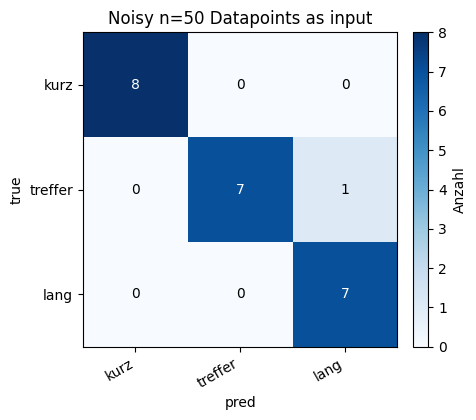

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Noisy n=50 Datapoints as input'}, xlabel='pred', ylabel='true'>)

In [10]:
batch_size = 64  # pro Schritt (anpassbar bei OOM)
effective_batch_size = 64  # Vergleich: identisch zur effektiven Batchsize im PINN
grad_accum_steps = max(1, int(effective_batch_size // batch_size))
assert effective_batch_size % batch_size == 0, "effective_batch_size muss Vielfaches von batch_size sein (für grad accumulation)."


tin = 50

# --- Dynamischer Rollout (rollout_until_ring): keine feste Future-Länge im Inferenz-/Eval-Pfad ---
# max_steps_cap ist nur eine Sicherheits-/Effizienz-Obergrenze (kein Horizontwissen als Feature).
max_steps_cap = 300
print("tin:", tin, "| max_steps_cap:", max_steps_cap)


df_train = df[df["wurf_id"].isin(train_ids)].reset_index(drop=True)
df_val   = df[df["wurf_id"].isin(val_ids)].reset_index(drop=True)
df_test  = df[df["wurf_id"].isin(test_ids)].reset_index(drop=True)

dsA_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsA_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlA_train = DataLoader(dsA_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlA_val   = DataLoader(dsA_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlA_test  = DataLoader(dsA_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelA = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histA = train_extrap(
    modelA, dlA_train, dlA_val,
    tin=tin,
    epochs=800, lr=2e-3, cls_weight=None, cls_target_ratio=0.01, calibrate_cls_weight=True, patience=25, grad_accum_steps=grad_accum_steps,
    max_steps_cap=max_steps_cap
)

# plot_history(histA, "Mode A (extrapolation) - ExtrapSeq2SeqModel")

cmA = eval_extrap(modelA, dlA_test, tin=tin,
    max_steps=max_steps_cap, split_name="test A")
plot_confusion_matrix(
    cm=cmA,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Noisy n=50 Datapoints as input",
)


## 8) Modus B (clean-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

tin: 30 | max_steps_cap: 300
[calib] cls_weight=0.0717834 (target_ratio=0.01, obs0=7.914, cls0=1.103)
[C] ep=001 tr_loss=7.9837 va_loss=7.1980 | tr_acc=0.234 va_acc=0.300 | va_mse_obs(1-step)=7.118999 | cls_w=0.0718 | bad=00/25
[C] ep=002 tr_loss=6.7992 va_loss=5.9731 | tr_acc=0.290 va_acc=0.400 | va_mse_obs(1-step)=5.894197 | cls_w=0.0718 | bad=00/25
[C] ep=003 tr_loss=5.4992 va_loss=4.1795 | tr_acc=0.346 va_acc=0.350 | va_mse_obs(1-step)=4.100602 | cls_w=0.0718 | bad=00/25
[C] ep=004 tr_loss=3.4905 va_loss=1.6055 | tr_acc=0.252 va_acc=0.350 | va_mse_obs(1-step)=1.526682 | cls_w=0.0718 | bad=00/25
[C] ep=005 tr_loss=1.1709 va_loss=0.5010 | tr_acc=0.327 va_acc=0.350 | va_mse_obs(1-step)=0.422332 | cls_w=0.0718 | bad=00/25
[C] ep=006 tr_loss=0.4823 va_loss=0.5360 | tr_acc=0.290 va_acc=0.350 | va_mse_obs(1-step)=0.457117 | cls_w=0.0718 | bad=01/25
[C] ep=007 tr_loss=0.5800 va_loss=0.6140 | tr_acc=0.336 va_acc=0.350 | va_mse_obs(1-step)=0.534897 | cls_w=0.0718 | bad=02/25
[C] ep=008 tr_lo

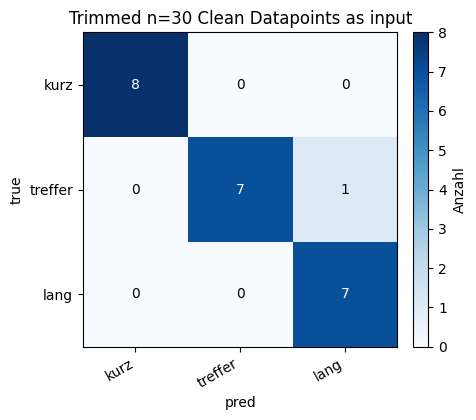

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Trimmed n=30 Clean Datapoints as input'}, xlabel='pred', ylabel='true'>)

In [11]:
tin = 30

# --- Dynamischer Rollout (rollout_until_ring): keine feste Future-Länge im Inferenz-/Eval-Pfad ---
max_steps_cap = 300
print("tin:", tin, "| max_steps_cap:", max_steps_cap)

dsB_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="clean", target_source="clean")
dsB_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlB_train = DataLoader(dsB_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlB_val   = DataLoader(dsB_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlB_test  = DataLoader(dsB_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelB = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histB = train_extrap(
    modelB, dlB_train, dlB_val,
    tin=tin,
    epochs=800, lr=2e-3, cls_weight=None, cls_target_ratio=0.01, calibrate_cls_weight=True, patience=25, grad_accum_steps=grad_accum_steps,
    max_steps_cap=max_steps_cap
)

# plot_history(histB, "Mode B (extrapolation) - ExtrapSeq2SeqModel")

cmB = eval_extrap(modelB, dlB_test, tin=tin,
    max_steps=max_steps_cap, split_name="test B")
plot_confusion_matrix(
    cm=cmB,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Trimmed n=30 Clean Datapoints as input",
)


## 9) Modus C (noisy-trimmed/extrapolation) mit ExtrapSeq2SeqModel
Encoder bekommt **Tin=30** noisy Punkte, Decoder erzeugt eine **vollständige, komplett vorhergesagte** Trajektorie (T=50 Punkte).

tin: 30 | max_steps_cap: 300
[calib] cls_weight=0.0678313 (target_ratio=0.01, obs0=7.44, cls0=1.097)
[C] ep=001 tr_loss=7.1956 va_loss=6.3881 | tr_acc=0.364 va_acc=0.300 | va_mse_obs(1-step)=6.313152 | cls_w=0.0678 | bad=00/25
[C] ep=002 tr_loss=5.9388 va_loss=4.6736 | tr_acc=0.336 va_acc=0.300 | va_mse_obs(1-step)=4.596531 | cls_w=0.0678 | bad=00/25
[C] ep=003 tr_loss=3.9719 va_loss=1.8962 | tr_acc=0.336 va_acc=0.300 | va_mse_obs(1-step)=1.817278 | cls_w=0.0678 | bad=00/25
[C] ep=004 tr_loss=1.4187 va_loss=0.7251 | tr_acc=0.364 va_acc=0.350 | va_mse_obs(1-step)=0.649680 | cls_w=0.0678 | bad=00/25
[C] ep=005 tr_loss=0.6930 va_loss=0.5951 | tr_acc=0.336 va_acc=0.350 | va_mse_obs(1-step)=0.520461 | cls_w=0.0678 | bad=00/25
[C] ep=006 tr_loss=0.5767 va_loss=0.4508 | tr_acc=0.327 va_acc=0.350 | va_mse_obs(1-step)=0.374955 | cls_w=0.0678 | bad=00/25
[C] ep=007 tr_loss=0.4364 va_loss=0.3491 | tr_acc=0.327 va_acc=0.350 | va_mse_obs(1-step)=0.273905 | cls_w=0.0678 | bad=00/25
[C] ep=008 tr_los

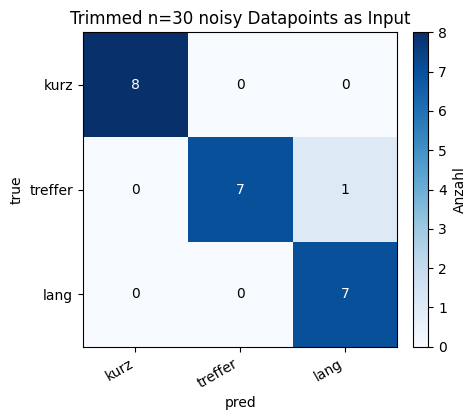

(<Figure size 500x430 with 2 Axes>,
 <Axes: title={'center': 'Trimmed n=30 noisy Datapoints as Input'}, xlabel='pred', ylabel='true'>)

In [12]:
tin = 30

# --- Dynamischer Rollout (rollout_until_ring): keine feste Future-Länge im Inferenz-/Eval-Pfad ---
max_steps_cap = 300
print("tin:", tin, "| max_steps_cap:", max_steps_cap)

dsC_train = ExtrapolationDataset(df_train, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_val   = ExtrapolationDataset(df_val, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_test  = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="noisy", target_source="noisy")
dsC_clean_test = ExtrapolationDataset(df_test, scaler, tin=tin, input_source="clean", target_source="clean")

dlC_train = DataLoader(dsC_train, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_extrap)
dlC_val   = DataLoader(dsC_val,   batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)
dlC_test  = DataLoader(dsC_test,  batch_size=batch_size, shuffle=False, collate_fn=collate_extrap)

modelC = ExtrapSeq2SeqModel(hidden_dim=128, num_layers=2, dropout=0.1).to(device)

histC = train_extrap(
    modelC, dlC_train, dlC_val,
    tin=tin,
    epochs=800, lr=2e-3, cls_weight=None, cls_target_ratio=0.01, calibrate_cls_weight=True, patience=25, grad_accum_steps=grad_accum_steps,
    max_steps_cap=max_steps_cap
)

# plot_history(histC, "Mode C (extrapolation) - ExtrapSeq2SeqModel")

cmC = eval_extrap(modelC, dlC_test, tin=tin,
    max_steps=max_steps_cap, split_name="test C")
plot_confusion_matrix(
    cm=cmC,
    class_names=["kurz", "treffer", "lang"],
    normalize=False,
    title="Trimmed n=30 noisy Datapoints as Input",
)


## 10) Qualitative Plots: Trajektorien (Ground Truth vs Prediction)
Wir plotten pro Modus ein Beispiel aus Test.

Wurf 89 | true label=2 | pred label=2
Tin=50 | dt_n=0.020408 | noisy→(pred) | clean GT


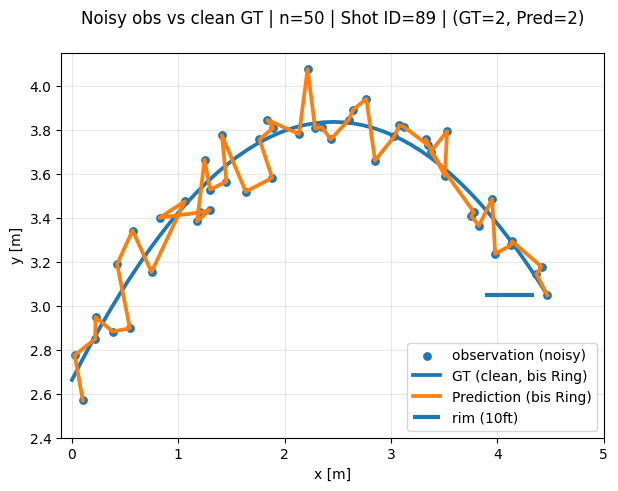

Wurf 1 | true label=1 | pred label=1
Tin=30 | dt_n=0.034483 | input=clean | target(GT)=clean


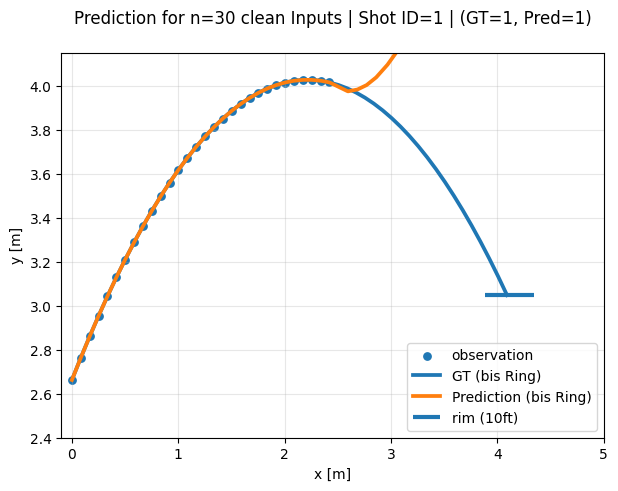

Wurf 71 | true label=2 | pred label=2
Tin=30 | dt_n=0.034483 | noisy→(pred) | clean GT


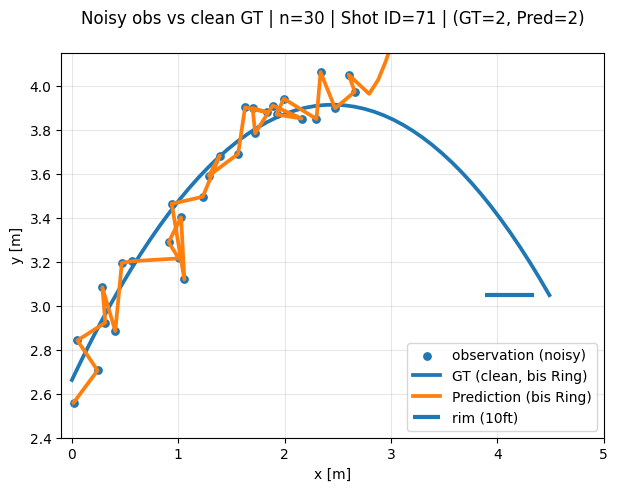

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch


H_RING_M = 3.048  # 10ft in meters (Korbebene)


# --- helper: time normalization exactly like in ExtrapolationDataset ---
def normalize_time_np(t_abs: np.ndarray, t_min: float, denom: float) -> np.ndarray:
    # t_abs: (T,1) float32
    denom = max(1e-8, float(denom))
    return (t_abs - float(t_min)) / denom


def _get_globals_or_raise(model, scaler, device, dg):
    if model is None:
        model = globals().get("model", None)
    if scaler is None:
        scaler = globals().get("scaler", None)
    if device is None:
        device = globals().get("device", None)
    if dg is None:
        dg = globals().get("dg", None)

    missing = [
        name
        for name, obj in [("model", model), ("scaler", scaler), ("device", device)]
        if obj is None
    ]
    if missing:
        raise RuntimeError(
            f"Fehlt im Scope: {missing}. Übergib sie als Parameter oder setze globale Variablen."
        )
    return model, scaler, device, dg


def _ring_crossing_idx_np(y: np.ndarray, y_ring: float = H_RING_M) -> int:
    """Erstes absteigendes Crossing y<=y_ring nach Apex. y: (T,) in Metern."""
    T = len(y)
    apex = int(np.argmax(y))
    for k in range(apex + 1, T):
        if (y[k] <= y_ring) and (y[k - 1] > y_ring):
            return k
    return T - 1


def _build_from_ds_groups(
    ds,
    scaler,
    idx: int,
    n_obs: int | None = None,
    input_source: str | None = None,
    target_source: str | None = None,
):
    """Baut alle Arrays/Tensors wie im Dataset, aber erlaubt n_obs override.

    Gibt zusätzlich unskalierte XYs in Metern fürs Plotten zurück.
    """
    wid = ds.throw_ids[idx]
    g = ds.groups[wid]

    T = len(g)
    Tin = int(n_obs) if n_obs is not None else int(ds.tin)
    assert 1 <= Tin <= T, f"Tin/n_obs={Tin} ist ungültig für T={T}"

    in_src = input_source if input_source is not None else ds.input_source
    tg_src = target_source if target_source is not None else ds.target_source

    # raw (meters)
    t_abs = g["t"].to_numpy(np.float32)[:, None]  # (T,1)
    xy_clean = g[["x_clean", "y_clean"]].to_numpy(np.float32)  # (T,2)
    xy_noisy = g[["x_noisy", "y_noisy"]].to_numpy(np.float32)  # (T,2)

    xy_in_m = xy_noisy if in_src == "noisy" else xy_clean  # for plotting obs
    xy_gt_m = xy_clean if tg_src == "clean" else xy_noisy  # for plotting GT

    # time norm (no future knowledge): denom based on last observed time
    t_min = float(t_abs[0, 0])
    t_obs_max = float(t_abs[Tin - 1, 0])
    denom = max(1e-8, (t_obs_max - t_min))
    t_n = normalize_time_np(t_abs, t_min, denom).astype(np.float32)  # (T,1)

    # Δt ausschließlich aus Beobachtungsfenster
    if Tin >= 2:
        dt_n = float(np.mean(np.diff(t_n[:Tin, 0])))
    else:
        dt_n = 0.0

    # scale XY like training
    xy_in_s = scaler.transform(xy_in_m)  # (T,2)
    xy_gt_s = scaler.transform(xy_gt_m)  # (T,2)

    # model tensors (match ExtrapolationDataset)
    x_in = np.concatenate([xy_in_s[:Tin], t_n[:Tin]], axis=1).astype(np.float32)  # (Tin,3)
    y_all = xy_gt_s.astype(np.float32)  # (T,2)

    # ring height in scaled space
    y_ring_scaled = (H_RING_M - float(scaler.mean_[0, 1])) / float(scaler.std_[0, 1])

    label = int(g["label"].iloc[0])

    return {
        "wurf_id": wid,
        "label": label,
        "Tin": Tin,
        "T": T,
        "t_min": t_min,
        "denom": float(denom),
        "dt_n": dt_n,
        "xy_obs_m": xy_in_m[:Tin],  # (Tin,2) meters
        "xy_gt_m": xy_gt_m,         # (T,2) meters
        "x_in": torch.from_numpy(x_in),          # (Tin,3)
        "dt": torch.tensor([dt_n], dtype=torch.float32),  # (1,)
        "y_all": torch.from_numpy(y_all),        # (T,2)
        "y_ring_scaled": torch.tensor([y_ring_scaled], dtype=torch.float32),  # (1,)
        "input_source": in_src,
        "target_source": tg_src,
    }


@torch.no_grad()
def demo_reconstruction(
    ds,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
    max_steps=300,
):
    """Qualitative Demo (ohne t_all): Rollout dynamisch bis Korbebene."""
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    s = _build_from_ds_groups(ds, scaler, idx=idx, n_obs=n_obs)
    wid = s["wurf_id"]

    model.eval()

    # dynamischer Rollout bis Ring (nur falls Zukunftsschritte benötigt werden)
    if (max_steps is None) or (int(max_steps) <= 0) or (s["Tin"] >= s["T"]):
        y_future = torch.zeros((1, 0, 2), device=device)
        stop_idx = torch.tensor([-1], device=device)
        S = 0
    else:
        y_future, stop_idx, S = model.rollout_until_ring(
            s["x_in"].unsqueeze(0).to(device),
            s["dt"].unsqueeze(0).to(device),
            s["y_ring_scaled"].unsqueeze(0).to(device),
            max_steps=max_steps,
        )
    y_future = y_future.squeeze(0)  # (S,2)

    # label prediction (aus Encoder-Kontext)
    _, logits = model(s["x_in"].unsqueeze(0).to(device), s["dt"].unsqueeze(0).to(device), n_future=0)
    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(s["label"])

    # inverse scale preds to meters
    y_future_m = scaler.inverse_transform(y_future.cpu().numpy())  # (S,2)

    # build full pred curve: observed + future
    xy_pred_m = np.vstack([s["xy_obs_m"], y_future_m])

    # GT until ring
    k_stop_gt = _ring_crossing_idx_np(s["xy_gt_m"][:, 1], y_ring=H_RING_M)
    xy_gt_cut = s["xy_gt_m"][: k_stop_gt + 1]

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(f"Tin={s['Tin']} | dt_n={s['dt_n']:.6f} | input={s['input_source']} | target(GT)={s['target_source']}")

    plt.figure(figsize=(7, 5))
    plt.scatter(s["xy_obs_m"][:, 0], s["xy_obs_m"][:, 1], s=28, label="observation")
    plt.plot(xy_gt_cut[:, 0], xy_gt_cut[:, 1], linewidth=2.7, label="GT (bis Ring)")
    plt.plot(xy_pred_m[:, 0], xy_pred_m[:, 1], linewidth=2.7, label="Prediction (bis Ring)")
    plt.hlines(
        y=H_RING_M,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )

    plt.title(
        f"Prediction for n={s['Tin']} {s['input_source']} Inputs | "
        f"Shot ID={wid} | (GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()


@torch.no_grad()
def demo_reconstruction_noisy_vs_clean(
    ds_noisy,
    ds_clean,
    idx=0,
    n_obs=None,
    model=None,
    scaler=None,
    device=None,
    dg=None,
    xlim=(-0.1, 5),
    ylim=(2.4, 4.15),
    max_steps=300,
):
    """Noisy-Obs vs Clean-GT Demo (ohne t_all): Rollout dynamisch bis Korbebene."""
    model, scaler, device, dg = _get_globals_or_raise(model, scaler, device, dg)

    # sample from noisy ds
    sN = _build_from_ds_groups(
        ds_noisy,
        scaler,
        idx=idx,
        n_obs=n_obs,
        input_source="noisy",
        target_source=ds_noisy.target_source,
    )
    wid = sN["wurf_id"]

    # build index cache for ds_clean by wurf_id
    if not hasattr(demo_reconstruction_noisy_vs_clean, "_clean_index") or getattr(
        demo_reconstruction_noisy_vs_clean, "_clean_index_ds_id", None
    ) != id(ds_clean):
        clean_index = {ds_clean.throw_ids[j]: j for j in range(len(ds_clean))}
        demo_reconstruction_noisy_vs_clean._clean_index = clean_index
        demo_reconstruction_noisy_vs_clean._clean_index_ds_id = id(ds_clean)

    clean_index = demo_reconstruction_noisy_vs_clean._clean_index
    if wid not in clean_index:
        raise KeyError(f"wurf_id={wid} nicht im ds_clean gefunden. Prüfe Split/IDs.")

    sC = _build_from_ds_groups(ds_clean, scaler, idx=clean_index[wid], n_obs=n_obs, input_source="clean", target_source="clean")

    # dynamischer Rollout aus noisy Input bis Ring (nur falls Zukunftsschritte benötigt werden)
    if (max_steps is None) or (int(max_steps) <= 0) or (sN["Tin"] >= sN["T"]):
        y_future = torch.zeros((1, 0, 2), device=device)
        stop_idx = torch.tensor([-1], device=device)
        S = 0
    else:
        y_future, stop_idx, S = model.rollout_until_ring(
            sN["x_in"].unsqueeze(0).to(device),
            sN["dt"].unsqueeze(0).to(device),
            sN["y_ring_scaled"].unsqueeze(0).to(device),
            max_steps=max_steps,
        )
    y_future = y_future.squeeze(0)
    y_future_m = scaler.inverse_transform(y_future.cpu().numpy())

    xy_pred_m = np.vstack([sN["xy_obs_m"], y_future_m])

    # GT clean bis Ring
    k_stop_gt = _ring_crossing_idx_np(sC["xy_gt_m"][:, 1], y_ring=H_RING_M)
    xy_gt_cut = sC["xy_gt_m"][: k_stop_gt + 1]

    # class pred
    _, logits = model(sN["x_in"].unsqueeze(0).to(device), sN["dt"].unsqueeze(0).to(device), n_future=0)
    pred_label = int(torch.argmax(logits, dim=1).item())
    gt_label = int(sN["label"])

    print(f"Wurf {wid} | true label={gt_label} | pred label={pred_label}")
    print(f"Tin={sN['Tin']} | dt_n={sN['dt_n']:.6f} | noisy→(pred) | clean GT")

    plt.figure(figsize=(7, 5))
    plt.scatter(sN["xy_obs_m"][:, 0], sN["xy_obs_m"][:, 1], s=28, label="observation (noisy)")
    plt.plot(xy_gt_cut[:, 0], xy_gt_cut[:, 1], linewidth=2.7, label="GT (clean, bis Ring)")
    plt.plot(xy_pred_m[:, 0], xy_pred_m[:, 1], linewidth=2.7, label="Prediction (bis Ring)")
    plt.hlines(
        y=H_RING_M,
        xmin=4.115 - 0.2286,
        xmax=4.115 + 0.2286,
        linewidth=3,
        label="rim (10ft)",
    )

    plt.title(
        f"Noisy obs vs clean GT | n={sN['Tin']} | Shot ID={wid} | (GT={gt_label}, Pred={pred_label})\n"
    )
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.show()


demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsA_test,
    ds_clean=dsA_clean_test,
    idx=14,
    n_obs=50,
    model=modelA,
    scaler=scaler,
    device=device,
)

demo_reconstruction(
    ds=dsB_test,
    idx=0,
    n_obs=30,
    model=modelB,
    scaler=scaler,
    device=device,
)

demo_reconstruction_noisy_vs_clean(
    ds_noisy=dsC_test,
    ds_clean=dsA_clean_test,
    idx=11,
    n_obs=30,
    model=modelC,
    scaler=scaler,
    device=device,
)
